# 02 — Pre-training SimMIM and Visualising Reconstruction

**Goal:** Run a SimMIM pre-training experiment and observe what the model learns to reconstruct.

| Section | What you will do |
|---------|------------------|
| Part 1 | Launch pre-training with **blank masking** and **Gaussian blur** |
| Part 2 | Load a saved checkpoint and inspect the reconstructions |
| Part 3 | Compare reconstructions across corruption types and mask ratios |

---
### Background: what is SimMIM doing?

SimMIM is a **masked image modelling** framework.  During pre-training:

1. A random subset of patches is **corrupted** (blanked or blurred).
2. The ViT encoder sees the **corrupted** image — no patch is ever truly hidden from it.
3. A lightweight pixel-space decoder predicts the **original clean** image.
4. The loss is the L1 distance between prediction and clean image.

The encoder must learn to infer what was behind the corruption — this forces it to build  
rich representations of local texture and global context.

In [1]:
import os, sys, importlib
from pathlib import Path

ROOT = Path('/Volumes/Extreme Pro/SimMIM_blur').resolve() # change this to your local path
assert ROOT.exists(), f"Root not found: {ROOT}"
assert (ROOT / 'models' / 'build_blur.py').exists(), \
    f"Cannot find models/build_blur.py under {ROOT}"

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
importlib.invalidate_caches()   # needed when path is added after kernel start

import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

from combined_launcher import run_launcher
from config import _C, _update_config_from_file
from models.build_blur import build_model

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f'torch {torch.__version__}  |  device: {device}')
print(f'ROOT: {ROOT}')

/opt/anaconda3/envs/project_transformer_py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/project_transformer_py312/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


torch 2.7.1  |  device: mps
ROOT: /Volumes/Extreme Pro/SimMIM_blur


---
## Part 1 — Pre-training

We call `main_simmim_blur.py` directly via `subprocess`, the same script the launcher uses internally.  
This way you can see and modify every argument that gets passed to the trainer.

The script accepts:
- a **config YAML** (`--cfg`) as the base configuration
- a **`--corruption`** flag (`blank` or `blur`) to choose the corruption type
- **`--opts KEY VALUE`** pairs to override any YACS config key at runtime

The cell below builds the full command, prints it so you can inspect it, then runs it.

In [2]:
# ── Fixed paths — no need to change these ─────────────────────
PRE_CFG    = ROOT / 'configs/vit_d6__cifar10/simmim_pretrain__vit_d6__cifar10__200ep.yaml'
DATA_ROOT  = ROOT / 'data_set'
OUT_ROOT   = ROOT / 'output_teaching' / 'pretrain'

assert PRE_CFG.exists(), f"Config not found: {PRE_CFG}"
print(f"Config : {PRE_CFG}")
print(f"Data   : {DATA_ROOT}")
print(f"Output : {OUT_ROOT}")

Config : /Volumes/Extreme Pro/SimMIM_blur/configs/vit_d6__cifar10/simmim_pretrain__vit_d6__cifar10__200ep.yaml
Data   : /Volumes/Extreme Pro/SimMIM_blur/data_set
Output : /Volumes/Extreme Pro/SimMIM_blur/output_teaching/pretrain


### Training parameters — change these

| Parameter | What it controls |
|-----------|-----------------|
| `CORRUPTION` | `'blank'` replaces patches with a constant; `'blur'` Gaussian-blurs them |
| `MASK_RATIO` | fraction of patches that are corrupted |
| `GAUSS_SIGMA` | blur bandwidth σ in cycles/image (only used when `CORRUPTION='blur'`) |
| `GAUSS_CUTOFF` | hard frequency cutoff in cycles/image — `None` means no cutoff |
| `EPOCHS` | set to 5–10 for a quick demo; 200 for a real run |

In [9]:
# ══════════════════════════════════════════════════════════════
#  CHANGE THESE
# ══════════════════════════════════════════════════════════════

# ── Patch sizes ────────────────────────────────────────────────
# VIT_PATCH_SIZE  : how the image is tokenised by the ViT encoder (MODEL.VIT.PATCH_SIZE)
# MASK_PATCH_SIZE : granularity at which patches are selected for corruption (DATA.MASK_PATCH_SIZE)
#
# Constraints (both must hold):
#   IMG_SIZE  % MASK_PATCH_SIZE == 0   →  32 % MASK_PATCH_SIZE == 0
#   MASK_PATCH_SIZE % VIT_PATCH_SIZE == 0
#
# For 32×32 CIFAR-10 with VIT_PATCH_SIZE=4, valid MASK_PATCH_SIZE values: 4, 8, 16, 32
# Larger MASK_PATCH_SIZE → coarser corruption blocks
VIT_PATCH_SIZE  = 4    # ViT tokenisation patch (MODEL.VIT.PATCH_SIZE)
MASK_PATCH_SIZE = 4    # corruption granularity  (DATA.MASK_PATCH_SIZE)

# ── Corruption ─────────────────────────────────────────────────
CORRUPTION   = 'blank'   # 'blank'  or  'blur'
MASK_RATIO   = 0.6       # fraction of patches to corrupt, e.g. 0.6 or 0.75

# Blank params  (only used when CORRUPTION = 'blank')
BLANK_VALUE  = 0.5       # fill colour: 0 = black, 1 = white, 0.5 = grey

# Gaussian blur params  (only used when CORRUPTION = 'blur')
#   σ in cycles / image — larger σ = less blur
#   pixel-space kernel width: σ_px = IMG_SIZE / (2π × σ_ci)
GAUSS_SIGMA  = 2.0       # cycles / image
GAUSS_CUTOFF = None      # hard frequency cutoff in cycles/image, or None

# ── Training ───────────────────────────────────────────────────
EPOCHS       = 1         # 5 for a quick demo; set to 200 for a real run
BATCH_SIZE   = 64        # reduce to 32 if you run out of memory
SEED         = 0
OUTPUT_TAG   = 'tutorial'

# ── Sanity checks ──────────────────────────────────────────────
assert 32 % MASK_PATCH_SIZE == 0, \
    f"IMG_SIZE 32 must be divisible by MASK_PATCH_SIZE={MASK_PATCH_SIZE}"
assert MASK_PATCH_SIZE % VIT_PATCH_SIZE == 0, \
    f"MASK_PATCH_SIZE={MASK_PATCH_SIZE} must be divisible by VIT_PATCH_SIZE={VIT_PATCH_SIZE}"
print(f"patch sizes OK  —  vit={VIT_PATCH_SIZE}  mask={MASK_PATCH_SIZE}")

patch sizes OK  —  vit=4  mask=4


### Build and run the training command

The cell below assembles the argument list, prints the full command so you can inspect it,  
then launches the training process.  Output (loss, lr, eta) will stream into the cell.

In [ ]:
import subprocess, shlex

# ── Build the CLI argument list ────────────────────────────────
corr_cli = 'blur' if CORRUPTION == 'blur' else 'blank'

args = [
    sys.executable, '-u', str(ROOT / 'main_simmim_blur.py'),
    '--cfg',             str(PRE_CFG),
    '--data-path',       str(DATA_ROOT),
    '--dataset',         'cifar10',
    '--cifar-download',
    '--corruption',      corr_cli,
    '--mask-ratio',      str(MASK_RATIO),
    '--mask-patch-size', str(MASK_PATCH_SIZE),
    '--output',          str(OUT_ROOT),
    '--tag',             OUTPUT_TAG,
    '--amp-opt-level',   'O0',
    '--loss-on-full-image',
    '--no-wandb'
]
# If you have wandb account (https://wandb.ai/site/) and want to log there, remove the '--no-wandb' flag and add:
if CORRUPTION == 'blank':
    args += ['--blank-value', str(BLANK_VALUE)]

# YACS overrides — these take effect on top of the YAML
opts = [
    'SEED',                      str(SEED),
    'TRAIN.EPOCHS',              str(EPOCHS),
    'DATA.BATCH_SIZE',           str(BATCH_SIZE),
    'DATA.NUM_WORKERS',          '0',
    'DATA.PIN_MEMORY',           'False',
    'MODEL.VIT.PATCH_SIZE',      str(VIT_PATCH_SIZE),
    'MODEL.VIT.DEPTH',           '6',
    'MODEL.VIT.EMBED_DIM',       '384',
    'MODEL.VIT.NUM_HEADS',       '12',
    'DATA.IMG_SIZE',             '32',
    'MODEL.NUM_CLASSES',         '10',
    'TRAIN.ACCUMULATION_STEPS',  '1',
]

if CORRUPTION == 'blur':
    opts += [
        'DATA.BLUR_TYPE',           'gaussian',
        'DATA.BLUR_GAUSS_SIGMA_CI', str(GAUSS_SIGMA),
    ]
    if GAUSS_CUTOFF is not None:
        opts += ['DATA.BLUR_GAUSS_CUTOFF_CI', str(float(GAUSS_CUTOFF))]

args += ['--opts'] + opts

# ── Print the full command ─────────────────────────────────────
print('Command:\n')
print(' \\\n  '.join(shlex.quote(a) for a in args))
print()

# ── Run ────────────────────────────────────────────────────────
result = subprocess.run(args, cwd=str(ROOT))
print('\n✓ Training complete' if result.returncode == 0
      else f'\n✗ Training failed  (returncode={result.returncode})')

Command:

/opt/anaconda3/envs/project_transformer_py312/bin/python \
  -u \
  '/Volumes/Extreme Pro/SimMIM_blur/main_simmim_blur.py' \
  --cfg \
  '/Volumes/Extreme Pro/SimMIM_blur/configs/vit_d6__cifar10/simmim_pretrain__vit_d6__cifar10__200ep.yaml' \
  --data-path \
  '/Volumes/Extreme Pro/SimMIM_blur/data_set' \
  --dataset \
  cifar10 \
  --cifar-download \
  --corruption \
  blank \
  --mask-ratio \
  0.6 \
  --mask-patch-size \
  4 \
  --output \
  '/Volumes/Extreme Pro/SimMIM_blur/output_teaching/pretrain' \
  --tag \
  tutorial \
  --amp-opt-level \
  O0 \
  --loss-on-full-image \
  --no-wandb \
  --blank-value \
  0.5 \
  --opts \
  SEED \
  0 \
  TRAIN.EPOCHS \
  1 \
  DATA.BATCH_SIZE \
  64 \
  DATA.NUM_WORKERS \
  0 \
  DATA.PIN_MEMORY \
  False \
  MODEL.VIT.PATCH_SIZE \
  4 \
  MODEL.VIT.DEPTH \
  6 \
  MODEL.VIT.EMBED_DIM \
  384 \
  MODEL.VIT.NUM_HEADS \
  12 \
  DATA.IMG_SIZE \
  32 \
  MODEL.NUM_CLASSES \
  10 \
  TRAIN.ACCUMULATION_STEPS \
  1



/opt/anaconda3/envs/project_transformer_py312/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


=> merge config from /Volumes/Extreme Pro/SimMIM_blur/configs/vit_d6__cifar10/simmim_pretrain__vit_d6__cifar10__200ep.yaml
[2026-03-25 10:27:31 simmim_pretrain](main_simmim_blur.py 856): INFO Full config saved to /Volumes/Extreme Pro/SimMIM_blur/output_teaching/pretrain/simmim_pretrain/tutorial/config.json
[2026-03-25 10:27:31 simmim_pretrain](main_simmim_blur.py 858): INFO [Device] device=mps | cuda=False | dist=False | world=1 | rank=0
[2026-03-25 10:27:31 simmim_pretrain](main_simmim_blur.py 859): INFO AMP_OPT_LEVEL: O0
AUG:
  AUTO_AUGMENT: rand-m9-mstd0.5-inc1
  COLOR_JITTER: 0.4
  CUTMIX: 1.0
  CUTMIX_MINMAX: null
  MIXUP: 0.8
  MIXUP_MODE: batch
  MIXUP_PROB: 1.0
  MIXUP_SWITCH_PROB: 0.5
  RECOUNT: 1
  REMODE: pixel
  REPROB: 0.25
BASE:
- ''
DATA:
  BATCH_SIZE: 64
  BLANK_VALUE: 0.5
  BLUR_GAUSS_CUTOFF_CI: 6.0
  BLUR_GAUSS_SIGMA_CI: 4.0
  BLUR_HEIGHT: 4
  BLUR_LEVELS:
  - residual_lowpass
  BLUR_NOISE_SEED: -1
  BLUR_NOISE_STD: 0.1
  BLUR_ORDER: 3
  BLUR_SEED: 0
  BLUR_TYPE: pyra

/opt/anaconda3/envs/project_transformer_py312/lib/python3.12/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1753838994289/work/aten/src/ATen/native/TensorShape.cpp:4316.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[2026-03-25 10:27:33 simmim_pretrain](utils.py 35): INFO <All keys matched successfully>
[2026-03-25 10:27:33 simmim_pretrain](utils.py 45): INFO => loaded successfully '/Volumes/Extreme Pro/SimMIM_blur/output_teaching/pretrain/simmim_pretrain/tutorial/ckpt_epoch_0.pth' (epoch 0)
[2026-03-25 10:27:33 simmim_pretrain](main_simmim_blur.py 683): INFO Start training
[2026-03-25 10:27:33 simmim_pretrain](metrics_plot.py 115): INFO [Plot] wrote /Volumes/Extreme Pro/SimMIM_blur/output_teaching/pretrain/simmim_pretrain/tutorial/loss_curves_rec.png (plotted train_rec/val_rec only)
[2026-03-25 10:27:33 simmim_pretrain](main_simmim_blur.py 786): INFO Training time 0:00:00

✓ Training complete


### What to look for during training

The cell above streams the trainer output directly.  You will see lines like:
```
Train  Epoch [1/5]  [  0/782]  eta 0:04:12  loss 0.1854  lr 2.10e-05
```

- **`loss` decreasing** across steps → the decoder is learning to reconstruct. ✓
- **`loss` stuck or NaN** → learning rate too high; try halving `BASE_LR` in the YAML.

Checkpoints are saved under:
```
output_teaching/pretrain/
  └── <run_name>/
        └── simmim_pretrain/
              └── tutorial/
                    ├── ckpt_epoch_1.pth
                    ├── ckpt_epoch_2.pth
                    └── ...
```

Run the cell below to list what was saved, then copy a path into Part 2.

In [11]:
ckpts = sorted(OUT_ROOT.rglob('*.pth'))
if ckpts:
    for p in ckpts:
        print(p)
else:
    print(f'No checkpoints found under {OUT_ROOT}')

/Volumes/Extreme Pro/SimMIM_blur/output_teaching/pretrain/simmim_pretrain/tutorial/._ckpt_epoch_0.pth
/Volumes/Extreme Pro/SimMIM_blur/output_teaching/pretrain/simmim_pretrain/tutorial/ckpt_epoch_0.pth


---
## Part 2 — Load a Checkpoint and Visualise Reconstructions

The model's `forward()` method accepts `return_inputs01=True`, which causes it to return
three pixel-space tensors in `[0, 1]` alongside the loss:

```python
loss, x_rec01, x_clean01, x_corr01 = model(x_norm, mask, return_inputs01=True)
#                 ↑ reconstruction   ↑ clean original   ↑ corrupted input
```

We will display these as a **triplet grid**: Original | Corrupted | Reconstructed.

In [12]:
# ══════════════════════════════════════════════════════════════
#  CHANGE THESE — point to the checkpoint you want to inspect
# ══════════════════════════════════════════════════════════════

# Paste the path printed by the cell above (adjust run_name accordingly)
# Example:
#   CKPT_PATH = SWEEP_OUT / 'M-SimMIM_ViT_d6_ps4_r60_emb384_h12_seed0_blankv0p5__pretr0p8' \
#                          / 'simmim_pretrain' / 'sweep' / 'ckpt_epoch_5.pth'
CKPT_PATH = '/Volumes/Extreme Pro/SimMIM_blur/output_teaching/pretrain/simmim_pretrain/tutorial/ckpt_epoch_0.pth' # <-- replace None with the actual Path

CORRUPTION_TYPE  = 'blank'   # 'blank' or 'blur' — must match what the checkpoint was trained with
GAUSS_SIGMA      = 1.0       # only used when CORRUPTION_TYPE == 'blur'
INFER_MASK_RATIO = 0.6       # mask ratio to use at inference time
N_VIZ            = 8         # images to show

assert CKPT_PATH is not None, 'Set CKPT_PATH to a .pth file printed above!'

In [13]:
# ── 1. Build config from the YAML ─────────────────────────────
config = _C.clone()
_update_config_from_file(config, str(PRE_CFG))

config.defrost()
config.DATA.CORRUPTION      = CORRUPTION_TYPE
config.DATA.DATASET         = 'cifar10'
config.DATA.IMG_SIZE        = 32
config.DATA.MASK_PATCH_SIZE = 4
config.DATA.MASK_RATIO      = INFER_MASK_RATIO
if CORRUPTION_TYPE == 'blur':
    config.DATA.BLUR_TYPE            = 'gaussian'
    config.DATA.BLUR_GAUSS_SIGMA_CI  = GAUSS_SIGMA
    config.DATA.BLUR_GAUSS_CUTOFF_CI = 0.0
config.MODEL.VIT.PATCH_SIZE = 4
config.MODEL.VIT.DEPTH      = 6
config.MODEL.VIT.EMBED_DIM  = 384
config.MODEL.VIT.NUM_HEADS  = 12
config.freeze()

# ── 2. Build model and move to device ─────────────────────────
model = build_model(config, is_pretrain=True)
model.eval()
model = model.to(device)

# weights_only=False is required because the checkpoint contains a
# yacs.config.CfgNode object (safe for locally-trained checkpoints)
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model'])
print(f'Loaded checkpoint  epoch={ckpt.get("epoch", "?")}  device={device}')

=> merge config from /Volumes/Extreme Pro/SimMIM_blur/configs/vit_d6__cifar10/simmim_pretrain__vit_d6__cifar10__200ep.yaml


/opt/anaconda3/envs/project_transformer_py312/lib/python3.12/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1753838994289/work/aten/src/ATen/native/TensorShape.cpp:4316.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Loaded checkpoint  epoch=0  device=mps


In [16]:
# ── 3. Prepare a batch of CIFAR-10 images ─────────────────────
CIFAR_ROOT = Path('/Volumes/Extreme Pro/SimMIM/data_set')
CIFAR_MEAN = torch.tensor([0.4914, 0.4822, 0.4465]).view(1, 3, 1, 1)
CIFAR_STD  = torch.tensor([0.2470, 0.2430, 0.2610]).view(1, 3, 1, 1)

dataset = torchvision.datasets.CIFAR10(
    root=str(CIFAR_ROOT), train=False, download=True,
    transform=transforms.ToTensor()
)
loader           = torch.utils.data.DataLoader(dataset, batch_size=N_VIZ, shuffle=True)
images01, labels = next(iter(loader))           # (B, 3, 32, 32) in [0, 1]

images_norm = (images01 - CIFAR_MEAN) / CIFAR_STD

def make_mask(B, H, W, patch_size, mask_ratio):
    Hb, Wb = H // patch_size, W // patch_size
    n = Hb * Wb
    k = int(n * mask_ratio)
    mask = torch.zeros(B, Hb, Wb, dtype=torch.bool)
    for i in range(B):
        idx = torch.randperm(n)[:k]
        mask[i, idx // Wb, idx % Wb] = True
    return mask

mask = make_mask(N_VIZ, 32, 32, patch_size=4, mask_ratio=INFER_MASK_RATIO)

# ── 4. Forward pass ───────────────────────────────────────────
with torch.no_grad():
    loss, x_rec01, x_clean01, x_corr01 = model(
        images_norm.to(device), mask.to(device), return_inputs01=True
    )

# move outputs back to CPU for matplotlib
x_rec01, x_clean01, x_corr01 = x_rec01.cpu(), x_clean01.cpu(), x_corr01.cpu()

print(f'Reconstruction L1 loss: {loss.item():.4f}')
print(f'Output shapes  —  clean: {tuple(x_clean01.shape)}  '
      f'corrupted: {tuple(x_corr01.shape)}  recon: {tuple(x_rec01.shape)}')

Reconstruction L1 loss: 0.6391
Output shapes  —  clean: (8, 3, 32, 32)  corrupted: (8, 3, 32, 32)  recon: (8, 3, 32, 32)


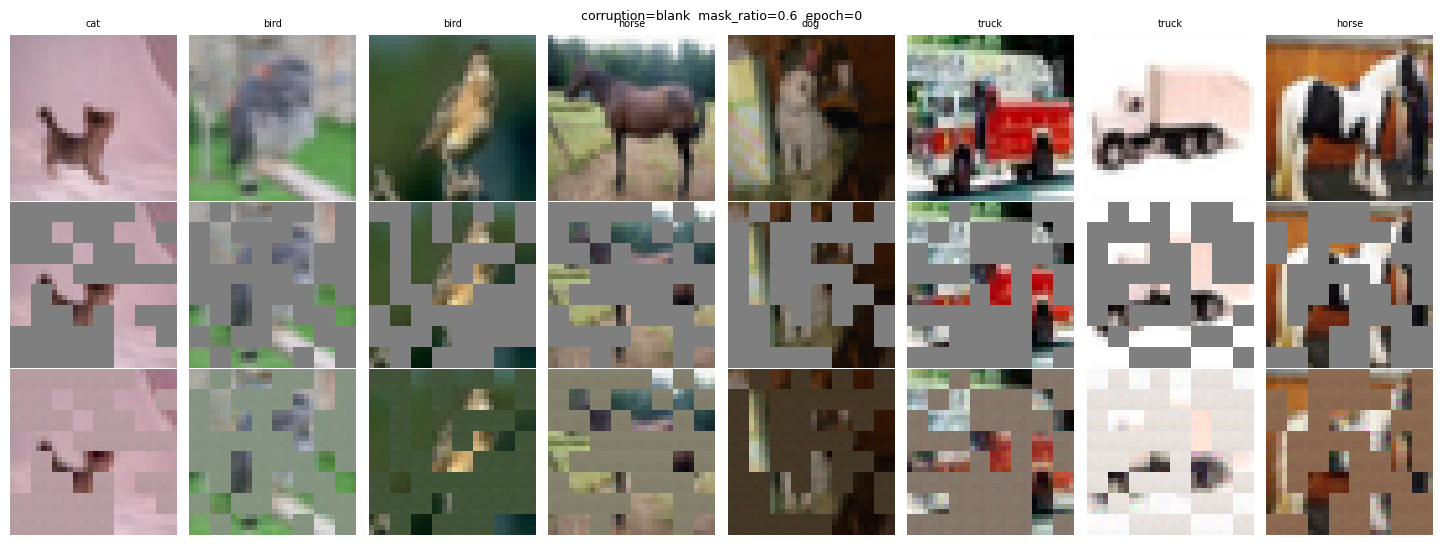

In [17]:
# ── 5. Visualise the triplet grid ─────────────────────────────
CLASSES = dataset.classes

def show_triplet(x_clean, x_corr, x_rec, labels, scale=1.8):
    """
    Display three rows: Original | Corrupted input | Reconstructed.
    All tensors: (B, 3, H, W) in [0, 1].
    """
    B      = x_clean.shape[0]
    rows   = [x_clean, x_corr, x_rec]
    titles = ['Original (clean)', 'Corrupted input', 'Reconstructed']

    fig, axes = plt.subplots(3, B, figsize=(B * scale, 3 * scale))
    for r, (imgs, title) in enumerate(zip(rows, titles)):
        axes[r, 0].set_ylabel(title, fontsize=9, rotation=0,
                              ha='right', va='center', labelpad=80)
        for c in range(B):
            axes[r, c].imshow(imgs[c].permute(1, 2, 0).clip(0, 1).numpy(),
                              interpolation='nearest')
            axes[r, c].axis('off')
            if r == 0:
                axes[r, c].set_title(CLASSES[labels[c]], fontsize=7)

    plt.suptitle(
        f'corruption={CORRUPTION_TYPE}  mask_ratio={INFER_MASK_RATIO}  '
        f'epoch={ckpt.get("epoch","?")}',
        fontsize=9
    )
    plt.tight_layout(pad=0.3)
    plt.show()

show_triplet(x_clean01, x_corr01, x_rec01, labels)

---
## Part 3 — Compare Across Conditions

Now that you have trained both blank and Gaussian models (and possibly at different mask ratios),
use the cell below to compare reconstructions side by side.

**Procedure:**
1. Fill in `CKPT_PATHS` with two or more checkpoint paths.
2. Set `LABELS` to a short description of each.
3. Run the cell — each column group shows one model's reconstruction of the same images.

In [ ]:
# ══════════════════════════════════════════════════════════════
#  CHANGE THESE — fill in paths to the checkpoints you trained
# ══════════════════════════════════════════════════════════════
CKPT_PATHS = [
    # (Path('...'), 'blank  r=0.6',  'blank'),
    # (Path('...'), 'gauss  \u03c3=1.0  r=0.6', 'blur'),
]

# ── shared batch ──────────────────────────────────────────────
torch.manual_seed(7)
loader2        = torch.utils.data.DataLoader(dataset, batch_size=6, shuffle=True)
imgs01, labs   = next(iter(loader2))
imgs_norm      = (imgs01 - CIFAR_MEAN) / CIFAR_STD
mask_compare   = make_mask(6, 32, 32, 4, INFER_MASK_RATIO)

recon_rows = [imgs01]
row_labels = ['Original']

for ckpt_path, label, corr_type in CKPT_PATHS:
    cfg2 = _C.clone()
    _update_config_from_file(cfg2, str(PRE_CFG))
    cfg2.defrost()
    cfg2.DATA.CORRUPTION      = corr_type
    cfg2.DATA.DATASET         = 'cifar10'
    cfg2.DATA.IMG_SIZE        = 32
    cfg2.DATA.MASK_PATCH_SIZE = 4
    cfg2.MODEL.VIT.PATCH_SIZE = 4
    cfg2.MODEL.VIT.DEPTH      = 6
    cfg2.MODEL.VIT.EMBED_DIM  = 384
    cfg2.MODEL.VIT.NUM_HEADS  = 12
    cfg2.freeze()

    m2 = build_model(cfg2, is_pretrain=True).to(device)
    m2.eval()
    ck2 = torch.load(ckpt_path, map_location=device, weights_only=False)
    m2.load_state_dict(ck2['model'])

    with torch.no_grad():
        _, rec, _, corr = m2(
            imgs_norm.to(device), mask_compare.to(device), return_inputs01=True
        )
    rec, corr = rec.cpu(), corr.cpu()

    if 'Corrupted' not in row_labels:
        recon_rows.append(corr)
        row_labels.append('Corrupted')
    recon_rows.append(rec)
    row_labels.append(f'Recon ({label})')
    print(f'{label:35s}  L1 loss = {torch.nn.functional.l1_loss(rec, imgs01).item():.4f}')

if len(CKPT_PATHS) > 0:
    nrows = len(recon_rows)
    ncols = recon_rows[0].shape[0]
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.8, nrows * 1.8))
    if nrows == 1:
        axes = axes[np.newaxis, :]
    for r, (imgs, title) in enumerate(zip(recon_rows, row_labels)):
        axes[r, 0].set_ylabel(title, fontsize=8, rotation=0, ha='right', va='center', labelpad=80)
        for c in range(ncols):
            axes[r, c].imshow(imgs[c].permute(1, 2, 0).clip(0, 1).numpy(), interpolation='nearest')
            axes[r, c].axis('off')
    plt.tight_layout(pad=0.3)
    plt.show()
else:
    print('Fill in CKPT_PATHS to enable the comparison.')

---
## Exercises

1. **Early reconstructions:**  
   After only 5 epochs, the reconstructions will look blurry or averaged.  
   Which corruption type gives sharper reconstructions at epoch 5 — blank or Gaussian?

2. **Effect of mask ratio:**  
   Compare reconstructions from a run with `mask_ratio=0.6` vs `mask_ratio=0.85`.  
   Does the model struggle more with higher mask ratios?  
   Which mask ratio forces the model to rely more on global context?

3. **Sigma and reconstruction difficulty:**  
   Train two Gaussian models: one with σ = 1.0, one with σ = 4.0.  
   For which σ is the reconstruction problem easier (lower loss)?  Why?

4. **What does the model hallucinate?**  
   Look at the reconstructed patches for wrong-looking regions.  
   Are errors more common at patch edges or interiors?  
   Does the model tend to fill in plausible textures or flat colours?

5. **Longer training:**  
   Set `PRE_EPOCHS = 50` and re-run one condition.  
   How much do the reconstructions improve?  
   At what epoch does the loss curve start to flatten?

